In [1]:
%load_ext autoreload
%autoreload 2

# An Open-source Supported Guide to High-speed Camera Based Structural Dynamics Identification

**D. Gorjup, K. Zaletelj, J. Slavič**  
University of Ljubljana, Faculty of Mechanical Engineering

*Mechanical Systems and Signal Processing*, TODO (TODO). DOI: [TODO](https://doi.org/TODO)

---

This notebook provides a complete, end-to-end worked example of the methods described in the paper above.
Each section maps directly to the corresponding paper section.

**How to cite:**
```bibtex
@article{gorjup2026tutorial,
  author  = {Gorjup, Domen and Zaletelj, Klemen and Slavi\v{c}, Janko},
  title   = {An Open-source Supported Guide to High-speed Camera Based Structural Dynamics Identification},
  journal = {Mechanical Systems and Signal Processing},
  year    = {TODO},
  volume  = {TODO},
  pages   = {TODO},
  doi     = {TODO},
}
```

Basic imports, used throughout the tutorial:

In [30]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

Import utility functions, used throughout the tutorial:

In [3]:
from methods import visualization # custom visualization utilities for plotting

---
## 2  Practical Considerations for Image-Based Vibration Measurement

This section covers the experimental setup steps that precede any displacement identification:
camera selection and configuration, geometric calibration, surface preparation, and an
overview of the main sources of measurement error.

### 2.1  Camera Selection and Setup

The High-speed camera image sequences, recorded in the example experiment, are provided in two versions:

* The **full-sized videos** are meant to represent a typical imaging setup in similar experiments.

    As the size of these videos is large, they are not uploaded to this tutorial soruce code repositoy. The access to the full image files will be provided upon request.

    The main image acquisition parameters of the full-size videos are as follows (provided by the included example Photron `.cih` metadata file):

Section-specific imports:

In [4]:
from pyMRAW import get_cih                  # library to interface with Photron MRAW, CIH and CIHX files
from methods.utils import metadata_overview # utility function to print metadata in a readable format

Load the Photron metadata (`.cih`) file to get basic information about the recorded video:

In [5]:
info_full = get_cih(os.path.join('.', 'data', 'mraw', 'view_0_01', 'view_0_01.cihx'))

In [6]:
metadata_overview(info_full)

Frame rate: 5000.0 fps
Number of frames: 10000
Image size (h x w): 768 x 768 pixels
Image bit depth: 8 bits per pixel
Approximate video size: 5.49 GB


* The **down-sized videos** are down-sized versions of the original videos, **provided as example data with this repository**.

    Using image downscaling and temporal downsampling, the original videos were converted to a more manageable size.

    The same raw image format and enough information to showcase the discussed methods were maintained by careful selection of the conversion parameters.

    The main characteristics of the down-sized videos are as follows (source: metadata of included Photron raw video files.)   

In [7]:
info_small = get_cih(os.path.join('.', 'data', 'mraw_downsized', 'view_0_01', 'view_0_01_downsized.cih'))

In [8]:
metadata_overview(info_small)

Frame rate: 1000.0 fps
Number of frames: 2000
Image size (h x w): 384 x 384 pixels
Image bit depth: 8 bits per pixel
Approximate video size: 0.27 GB


### 2.2  Camera Calibration

The pinhole model relates a 3-D world point $\mathbf{X}$ to its image projection $\mathbf{x}$ via the intrinsic matrix $\mathbf{K}$ and the extrinsic pose ($\bm{R}$, $\bm{t}$).  
Calibration is performed with a planar checkerboard target; quality is assessed by the reprojection error.

Section-specific imports:

In [9]:
import cv2 # OpenCV library for image processing
from methods import calibration # camera calibration utiilities

#### Intrinsic calibration

Intrinsic calibration can be achieved using the classic Zhang's calibration method, using images of a well defined checkerboard pattern (see *Sec. 2.2*).

Find intrinsic calibration images of the checkeboard pattern:

In [15]:
calibration_images_zhang = glob.glob(os.path.join('.', 'data', 'calibration', '*.jpg'))

Perfrom camera calibratio using Zhang's method, implemented in [OpenCV](https://docs.opencv.org/3.4/dc/dbb/tutorial_py_calibration.html).

In [16]:
K, calibration_parameters = calibration.calibrate_camera(
    calibration_images_zhang,   # list of file paths to calibration images
    pattern_size=(6, 4),        # number of inner corners per chessboard row and column
    block_size=20               # size of each square in the chessboard pattern (in mm)
    )

Let's look at a sumamry of the calibration procedure:

Intrinsic parameters
  Focal length : fx = 2142.94 px  (42.859 mm),  fy = 2140.70 px  (42.814 mm)
  Principal pt : cx = 372.42 px,  cy = 412.71 px
  Skew         : s  = 0.00000
Reprojection error  mean = 0.0866 px,  max = 0.1165 px


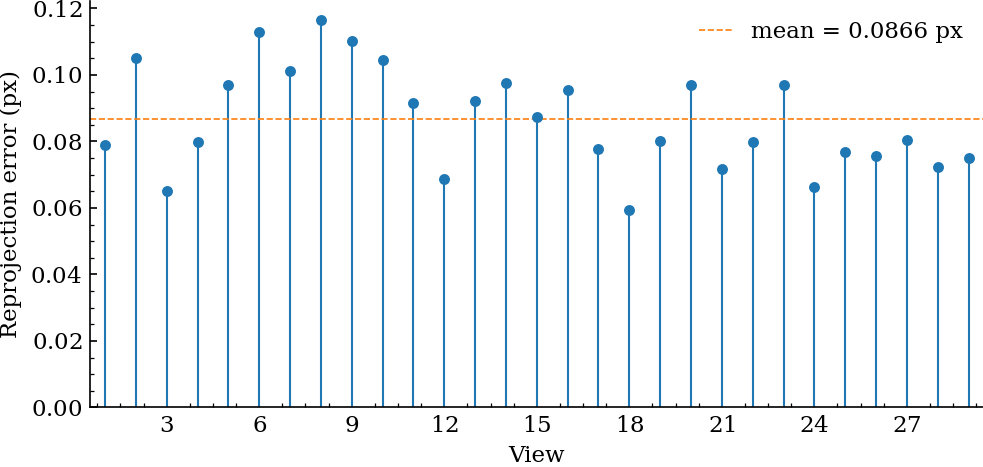

In [17]:
reprojection_error_figure = calibration.print_calibration_summary(K, calibration_parameters, 
                                sensor_width_mm=20.48, sensor_width_px=1024) # Photron sensor dimentions, to convert focal length from pixels to mm

Visualize the calibration results:

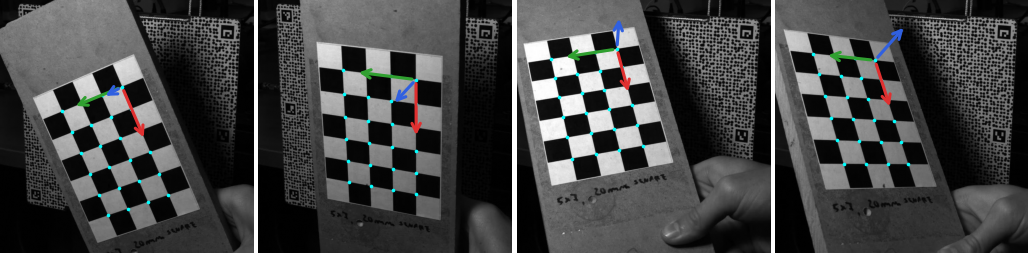

In [28]:
fig, ax = calibration.plot_calibration_images(K, calibration_parameters, 4, show_axes=True)
# plt.savefig(os.path.join('output', 'figures', 'fig_3_calibration_images_zhang.png'))

#### Extrinsic calibration

Extrinsic calibration estimates the pose (position and orientation) of each camera in the world frame. 
A set of ArUco fiducial markers with known 3-D locations serves as the reference - their image positions are detected automatically and passed to the PnP solver together with the intrinsic parameters from the previous step.

Section-specific imports

In [34]:
import pyMRAW # library to interface with Photron MRAW, CIH and CIHX files

In [35]:
from methods.calibration import calibrate_extrinsic, camera_position, plot_scene

Specify the two measurement view files and load the first frame from each:

In [38]:
view_files = {
    'view 0': os.path.join('.', 'data', 'mraw_downsized', 'view_0_01', 'view_0_01_downsized.cih'),
    'view 1': os.path.join('.', 'data', 'mraw_downsized', 'view_1_01', 'view_1_01_downsized.cih'),
}

reference_frames = {
    'view 0': pyMRAW.load_video(view_files['view 0'])[0][0], # load first frame of view 0
    'view 1': pyMRAW.load_video(view_files['view 1'])[0][0],
}

Load the ArUco reference marker layout — 6 markers printed on the speckle plate, with known positions in the plate coordinate system ($z = 0$):

In [43]:
aruco_info_path = os.path.join('.', 'data', 'mraw', 'ArUco_info_prusa_plate_speckle_4X4_50_3mm.pkl')
with open(aruco_info_path, 'rb') as f:
    aruco_info = pickle.load(f)

# Build {marker_id: (x, y, z)} dict — markers lie on a flat plate so z = 0
markers_3d = {
    int(aruco_info['IDs'][i]): np.append(aruco_info['centers_mm'][i], 0.)
    for i in range(len(aruco_info['IDs']))
  }

In [44]:
markers_3d

{0: array([13., 13.,  0.]),
 1: array([ 13., 241.,   0.]),
 2: array([120.,  13.,   0.]),
 3: array([120., 241.,   0.]),
 4: array([227.,  13.,   0.]),
 5: array([227., 241.,   0.])}

Detect ArUco markers in the reference frame of each view and record their image-plane centres:

In [47]:
markers_2d = {}
for label, frame in reference_frames.items():
  markers_2d[label] = calibration.detect_aruco_markers(frame)
  print(f'{label}: detected IDs {sorted(markers_2d[label].keys())}')

view 0: detected IDs [0, 1, 2, 4, 5]
view 1: detected IDs [0, 1, 2, 3, 4, 5]


Perform extrinsic calibration based on detected markers:

In [48]:
camera_matrices = {}
for label in view_files:
    obj_pts, img_pts = calibration.match_marker_points(markers_3d, markers_2d[label])
    camera_matrices[label], _ = calibration.calibrate_extrinsic(obj_pts, img_pts, K,
calibration_parameters)

Extrinsic calibration reprojection error: 5.2906 px
Extrinsic calibration reprojection error: 3.0558 px


(The reprojection error measures how accurately the estimated pose maps known 3D marker positions back to their detected pixel locations. Values below ~2 px are acceptable for a small marker set on downsized images, but lower reprojection errors are preferable in critical real-world experiments.)


Visualise the measurement scene — reference marker positions and estimated camera poses:

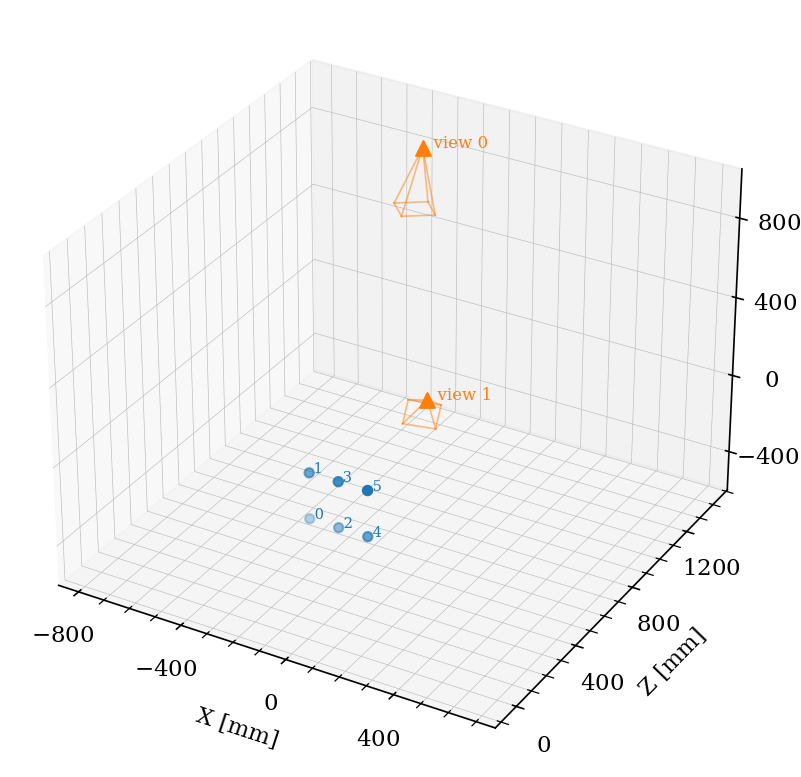

In [54]:
marker_positions = np.array([markers_3d[i] for i in sorted(markers_3d)])
marker_labels = list(sorted(markers_3d.keys()))

fig, ax = calibration.plot_scene(marker_positions, camera_matrices,
                                  K=K, frustum_size=300,
                                  marker_labels=marker_labels)
# plt.savefig(os.path.join('output', 'figures', 'fig_extrinsic_scene.png'))

### 2.3  Lighting and Surface Preparation

Adequate, uniform illumination and a high-contrast speckle pattern are prerequisites for
reliable sub-pixel displacement estimation.  The histogram below illustrates a well-exposed
speckle pattern.

In [ ]:
# TODO: load a sample speckle image and plot its intensity histogram

### 2.4  Sources of Measurement Error

Primary error sources: image noise, blur (motion and defocus), aliasing, lens distortion,
and illumination variation.

In [ ]:
# TODO: demonstrate effect of one or more error sources (e.g. SNR vs. displacement bias)

---
## 3  Identifying Displacements in Digital Images

Two complementary paradigms are presented: **optical flow** (Eulerian, dense or sparse)
and **Digital Image Correlation** (Lagrangian, subset-based).  Both are implemented in
[pyIDI](https://github.com/ladisk/pyidi).

### 3.1  Optical Flow Displacement Identification

The brightness constancy assumption yields the optical flow constraint equation:

$$\frac{\partial I}{\partial x} u + \frac{\partial I}{\partial y} v + \frac{\partial I}{\partial t} = 0$$

The Lucas–Kanade method resolves the aperture problem by assuming uniform flow within a
small spatial window and solving the resulting over-determined system in a least-squares sense.

In [ ]:
import pyidi

# TODO: load video with pyidi.VideoReader, initialise LucasKanade method,
#       set_points(), run get_displacements(), plot displacement time series

### 3.2  Digital Image Correlation (DIC)

DIC tracks a subset of pixels by maximising a normalised cross-correlation (ZNCC) or
minimising a sum-of-squared-differences (SSD / ZNSSD) criterion over deformation parameters
described by a shape function.

In [ ]:
# TODO: demonstrate subset-based DIC with pyIDI; compare similarity measures (SSD, ZNCC)

### 3.3  Similarity Measures

The choice of similarity measure affects robustness to illumination changes and noise.
ZNSSD / ZNCC are invariant to linear intensity shifts and scaling.

In [ ]:
# ex_4_2_subset_size
# TODO: sweep subset size and plot the trade-off between spatial resolution and noise

### 3.4  Image-based Displacement Identification for High-Frequency Vibration

At high vibration frequencies relative to the frame rate, amplitude and phase estimates
can be recovered from sub-Nyquist aliased signals if the excitation is periodic and the
aliasing pattern is known.

In [ ]:
# TODO: demonstrate high-frequency identification from aliased camera data

---
## 4  Measuring 3D Displacements from Digital Images

A single camera provides 2-D projections only.  3-D displacements are recovered either via
**stereo triangulation** (geometric, using calibrated camera pairs) or **frequency-domain
triangulation** (exploiting the out-of-plane to in-plane displacement ratio at resonance).

### 4.1  Multi-view Imaging and Triangulation

The Direct Linear Transform (DLT) assembles, for each camera view, two linear equations
in the unknown 3-D point **X**.  With ≥ 2 views the over-determined system is solved by SVD.

In [ ]:
# TODO: given two sets of 2-D displacement time series (camera 1 and 2) and calibration
#       matrices P1, P2, assemble DLT system and recover 3-D displacements via SVD

### 4.2  Frequency-Domain Triangulation

At each resonance frequency the 3-D mode shape vector can be recovered from the complex
spectra of the 2-D projected displacements, using the known projection matrices.

In [ ]:
# TODO: compute displacement spectra from multiple camera views, apply frequency-domain
#       triangulation at identified resonance frequencies, visualise 3-D deflection shapes

### 4.3  When Is 3D Measurement Necessary?

For planar structures or in-plane dominant modes a single camera is sufficient.
This cell provides a simple criterion based on the expected out-of-plane to in-plane ratio.

In [ ]:
# TODO: quantitative example or figure illustrating when 3-D reconstruction adds value

---
## 5  Experimental Modal Analysis Using Image-based Measurements

Camera-derived displacement time series are used to estimate FRFs, extract modal parameters
(natural frequencies, damping, mode shapes), and validate them against reference data.

### 5.1  Frequency Response Functions

H₁ and H₂ FRF estimators are computed from cross- and auto-spectral density matrices
using Welch's averaged periodogram method.  Coherence provides a quality indicator.

In [ ]:
# ex_6_1_frf_estimation
# TODO: load force and displacement signals, compute H1 / H2 estimators and coherence,
#       plot FRF magnitude and phase

### 5.2  The Hybrid Modal Identification Method

Natural frequencies and damping ratios are identified from high-quality accelerometer FRFs
using LSCF (poly-reference Least-Squares Complex Frequency).  Mode shapes are then extracted
at those poles from the full camera FRF matrix using LSFD.

In [ ]:
import sdypy as sd

# TODO: run LSCF on accelerometer FRFs to obtain poles (natural frequencies + damping),
#       then LSFD on camera FRFs to extract full-field mode shapes

### 5.3  Validating Camera-based Mode Shapes Using the Modal Assurance Criterion

The Modal Assurance Criterion (MAC) quantifies the correlation between two mode shape vectors:

$$\text{MAC}(\boldsymbol{\phi}_r, \boldsymbol{\psi}_r) =
\frac{|\boldsymbol{\phi}_r^\mathrm{H} \boldsymbol{\psi}_r|^2}
{(\boldsymbol{\phi}_r^\mathrm{H} \boldsymbol{\phi}_r)(\boldsymbol{\psi}_r^\mathrm{H} \boldsymbol{\psi}_r)}$$

A value close to 1 indicates good agreement; off-diagonal values should be near zero.

In [ ]:
# TODO: compute MAC matrix between camera-based and reference (accelerometer / FE) mode shapes,
#       plot as a colour matrix